### Differential Equations and Linear Algebra | Gilbert Strang | Solutions and Code by David A. Lee
### Chapter 8: Fourier and Laplace Transforms
#### Section 8.1: Fourier Series

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, animation_style, saveanim, neon_cmap

Question 8.1.2

In [2]:
def style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=None, ylim=None,
             xticks=None, xticklabels=None, yticks=None, yticklabels=None,
             color=FG, fontsize=16):
    """Apply shared plot attributes to one or more axes."""
    axes = np.atleast_1d(ax)
    for a in axes:
        a.set_xlabel(xlabel, color=color, fontsize=fontsize)
        a.set_ylabel(ylabel, color=color, fontsize=fontsize)
        a.tick_params(colors=color)
        a.tick_params(labelsize=fontsize)
        a.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
        a.grid(False)
        if xlim is not None:
            a.set_xlim(xlim)
        if ylim is not None:
            a.set_ylim(ylim)
        if xticks is not None:
            a.set_xticks(xticks)
        if xticklabels is not None:
            a.set_xticklabels(xticklabels, color=color)
        if yticks is not None:
            a.set_yticks(yticks)
        if yticklabels is not None:
            a.set_yticklabels(yticklabels, color=color)

saved chap8sec8.1ex2.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.1\chap8sec8.1ex2.pdf


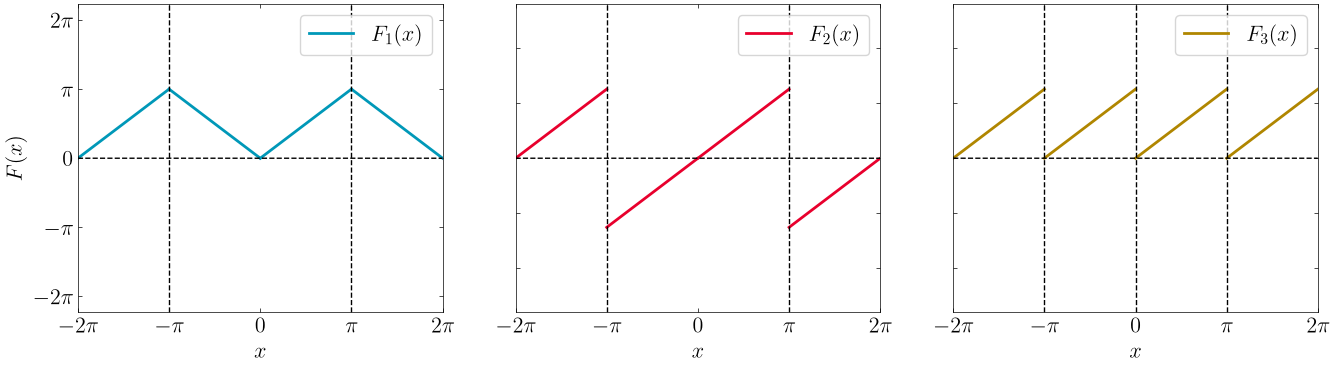

In [3]:
x = np.arange(-2*np.pi, 2*np.pi, 0.01)
x1 = np.arange(-2*np.pi, -np.pi, 0.01)
x2 = np.arange(-np.pi, 0, 0.01)
x3 = np.arange(0, np.pi, 0.01)
x4 = np.arange(np.pi, 2*np.pi, 0.01)


fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# Same attributes for each plot
pi_ticks = [-2*np.pi, -np.pi, 0, np.pi, 2*np.pi]
pi_labels = [r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$', r'$2\pi$']

# All axes: x-label, limits, x-ticks, tick params, no grid
style_ax(ax, xlabel='$x$', ylabel='', xlim=(-2*np.pi, 2*np.pi), ylim=(-7, 7),
         xticks=pi_ticks, xticklabels=pi_labels)

# Left plot only: y-label and y-tick labels
ax[0].set_ylabel('$F(x)$', color=FG, fontsize=16)
ax[0].set_yticks(pi_ticks)
ax[0].set_yticklabels(pi_labels, color=FG)

# Middle and right: no y-tick labels
for a in ax[1:]:
    a.set_yticklabels([])

# Plot curves on each of the 3 axes
ax[0].plot(x1, 2*np.pi + x1, color=C.cyan, linewidth=2)
ax[0].plot(x2, -x2, color=C.cyan, linewidth=2)
ax[0].plot(x3, x3, color=C.cyan, linewidth=2)
ax[0].plot(x4, 2*np.pi - x4, color=C.cyan, linewidth=2, label="$F_1(x)$")

ax[1].plot(x1, 2*np.pi + x1, color=C.red, linewidth=2)
ax[1].plot(x2, x2, color=C.red, linewidth=2)
ax[1].plot(x3, x3, color=C.red, linewidth=2)
ax[1].plot(x4, -2*np.pi + x4, color=C.red, linewidth=2, label="$F_2(x)$")

ax[2].plot(x1, 2*np.pi + x1, color=C.yellow, linewidth=2)
ax[2].plot(x2, np.pi + x2, color=C.yellow, linewidth=2)
ax[2].plot(x3, x3, color=C.yellow, linewidth=2)
ax[2].plot(x4, -np.pi + x4, color=C.yellow, linewidth=2, label="$F_3(x)$")
ax[2].vlines(0, -7, 7, color=FG, linestyle='--', linewidth=1)

for a in ax:
    a.plot(x, 0*x, color=FG, linestyle='--', linewidth=1)
    a.vlines(np.pi, -7, 7, color=FG, linestyle='--', linewidth=1)
    a.vlines(-np.pi, -7, 7, color=FG, linestyle='--', linewidth=1)
    a.legend(frameon=True, fontsize=16)

savefig(fig, "chap8sec8.1ex2.pdf", bbox_inches=None)
plt.show()

Question 8.1.6

saved chap8sec8.1ex6.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.1\chap8sec8.1ex6.pdf


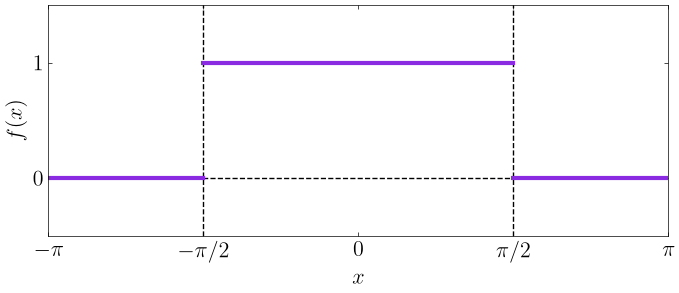

In [4]:
x1 = np.arange(-np.pi / 2, np.pi / 2, 0.01)
x2 = np.arange(-np.pi, -np.pi / 2, 0.01)
x3 = np.arange(np.pi / 2, np.pi, 0.01)


fig, ax = plt.subplots(figsize=(8, 3))

# Same attributes for each plot
pi_ticks = [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
pi_labels = [r'$-\pi$', r'$-\pi / 2$', r'$0$', r'$\pi / 2$', r'$\pi$']

# Set tick params to white
ax.tick_params(colors=FG)
ax.tick_params(labelsize=16)

# Remove grid and minor ticks
ax.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
ax.grid(False)

# Set aspect ratio and limits
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-0.5, 1.5)

# y-label and y-tick labels
ax.set_xlabel('$x$', color=FG, fontsize=16)
ax.set_ylabel('$f(x)$', color=FG, fontsize=16)
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels, color=FG)
ax.set_yticks([0, 1])

# Plot curves on each of the 3 axes
ax.hlines(0, -np.pi, np.pi, color=FG, linestyle='--', linewidth=1)
ax.vlines(-np.pi/2, -0.5, 1.5, color=FG, linestyle='--', linewidth=1)
ax.vlines(np.pi/2, -0.5, 1.5, color=FG, linestyle='--', linewidth=1)
ax.plot(x1, np.ones(len(x1)), color=C.violet, linewidth=3)
ax.plot(x2, np.ones(len(x2))*0, color=C.violet, linewidth=3)
ax.plot(x3, np.ones(len(x3))*0, color=C.violet, linewidth=3)

savefig(fig, "chap8sec8.1ex6.pdf", bbox_inches=None)
plt.show()

saved chap8sec8.1ex7.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.1\chap8sec8.1ex7.pdf


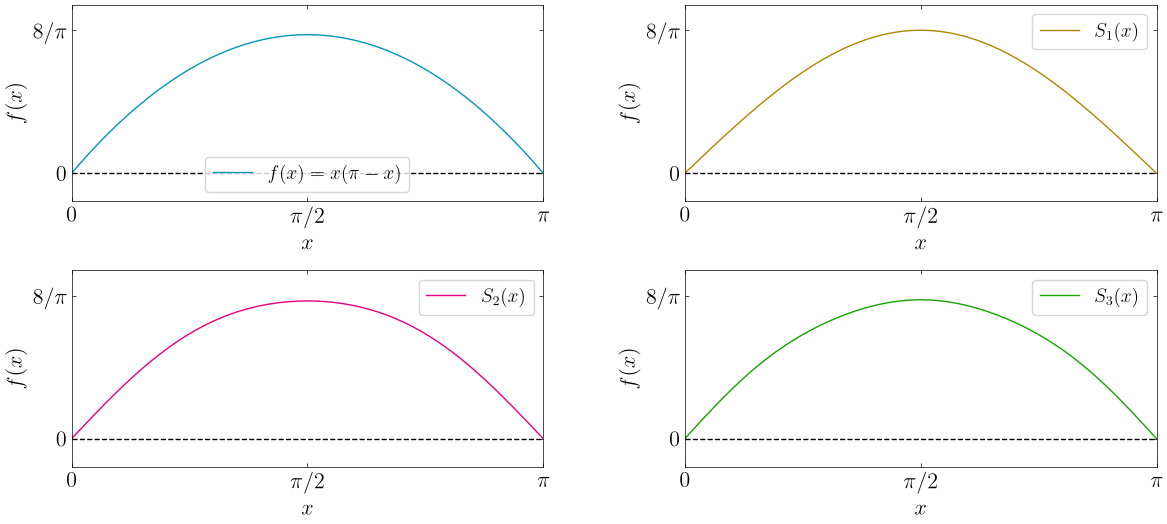

In [5]:
x = np.arange(0, np.pi, 0.01)
c = 8 / np.pi
f = x*(np.pi - x)
f1 = c*np.sin(x)
f2 = c*np.sin(3*x) / 27
f3 = c*np.sin(5*x) / 125


fig, ax = plt.subplots(2, 2, figsize=(14, 6))

pi_ticks = [0, np.pi/2, np.pi]
pi_labels = [r'$0$', r'$\pi/2$', r'$\pi$']

y_labels = [r'$0$', r'$8/\pi$']

# Shared styling and limits for all axes
for a in ax.flat:
    style_ax(a, xlabel='$x$', ylabel='$f(x)$',
             xlim=(0, np.pi), ylim=(-0.5, 3),
             xticks=pi_ticks, xticklabels=pi_labels,
             yticks=[0, 8 / np.pi], yticklabels=y_labels)
    a.hlines(0, 0, np.pi, color=FG, linestyle='--', linewidth=1)

# Subplot (0,0): f
ax[0,0].plot(x, f, color=C.cyan, linewidth=1, label=r'$f(x) = x(\pi - x)$')
ax[0,0].legend(frameon=True, fontsize=14)

# Subplot (0,1): first partial sum
ax[0,1].plot(x, f1, color=C.yellow, linewidth=1, label=r'$S_1(x)$')
ax[0,1].legend(frameon=True, fontsize=14)

# Subplot (1,0): second partial sum
ax[1,0].plot(x, f1 + f2, color=C.magenta, linewidth=1, label=r'$S_2(x)$')
ax[1,0].legend(frameon=True, fontsize=14)

# Subplot (1,1): third partial sum
ax[1,1].plot(x, f1 + f2 + f3, color=C.green, linewidth=1, label=r'$S_3(x)$')
ax[1,1].legend(frameon=True, fontsize=14)

fig.subplots_adjust(wspace=0.3, hspace=0.35)
savefig(fig, "chap8sec8.1ex7.pdf", bbox_inches=None)
plt.show()

Question 8.1.8

saved chap8sec8.1ex8.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.1\chap8sec8.1ex8.pdf


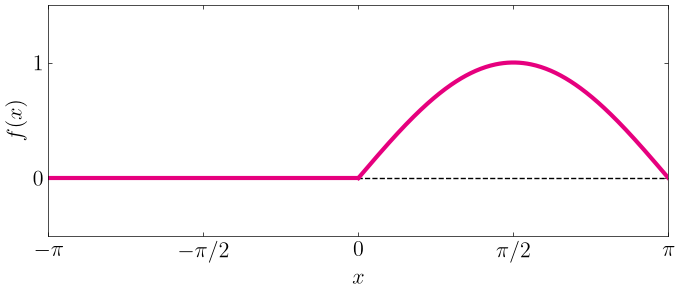

In [6]:
x1 = np.arange(-np.pi, 0, 0.01)
x2 = np.arange(0, np.pi, 0.01)


fig, ax = plt.subplots(figsize=(8, 3))

pi_ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
pi_labels = [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']

y_labels = [r'$0$', r'$1$']

# Set tick params to white
ax.tick_params(colors=FG)
ax.tick_params(labelsize=16)

# Remove grid and minor ticks
ax.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
ax.grid(False)

# Set aspect ratio and limits
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-0.5, 1.5)

# y-label and y-tick labels
ax.set_xlabel('$x$', color=FG, fontsize=16)
ax.set_ylabel('$f(x)$', color=FG, fontsize=16)
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels, color=FG)
ax.set_yticks([0, 1])

# Plot
ax.hlines(0, -np.pi, np.pi, color=FG, linestyle='--', linewidth=1)
ax.plot(x1, np.ones(len(x1))*0, color=C.magenta, linewidth=3)
ax.plot(x2, np.sin(x2), color=C.magenta, linewidth=3)

savefig(fig, "chap8sec8.1ex8.pdf", bbox_inches=None)
plt.show()

Question 8.1.19

N=5: Gibbs overshoot ≈ 0.09116 (fraction 0.09116) at x ≈ 1.25666
N=10: Gibbs overshoot ≈ 0.08991 (fraction 0.08991) at x ≈ 1.41371
N=100: Gibbs overshoot ≈ 0.08949 (fraction 0.08949) at x ≈ 1.55507
N=1000: Gibbs overshoot ≈ 0.08949 (fraction 0.08949) at x ≈ 1.56922
saved chap8sec8.1ex19.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.1\chap8sec8.1ex19.pdf


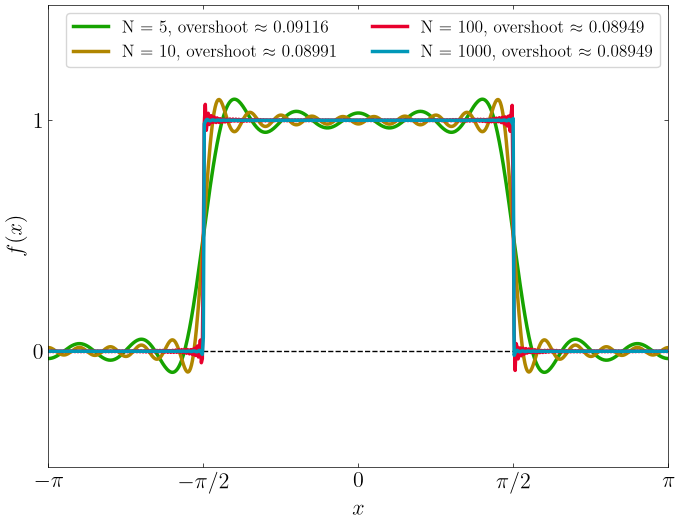

In [7]:
x = np.arange(-np.pi, np.pi, 0.01)

def f_vectorized(x, N=50):
    x = np.array(x)
    n = np.arange(1, N + 1)
    coeffs = (-1)**(n + 1) * 2 / (np.pi * (2*n - 1))
    terms = coeffs[:, None] * np.cos((2*n - 1)[:, None] * x)
    return 0.5 + terms.sum(axis=0)

def gibbs_overshoot(f_series, jump_point, jump_left, jump_right,
                    N=200, window=0.5, resolution=20000):
    """
    Estimate Gibbs overshoot numerically.

    Parameters
    ----------
    f_series : callable
        Function like f_vectorized(x, N=...)
    jump_point : float
        Location of discontinuity
    jump_left : float
        Left-hand limit of original function
    jump_right : float
        Right-hand limit of original function
    N : int
        Number of Fourier terms
    window : float
        Size of interval around jump to search
    resolution : int
        Number of sample points in search interval

    Returns
    -------
    overshoot : float
    fraction_of_jump : float
    peak_location : float
    peak_value : float
    """
    
    # sample region around the jump
    x = np.linspace(jump_point - window,
                    jump_point + window,
                    resolution)

    y = f_series(x, N=N)

    peak_index = np.argmax(y)
    peak_value = y[peak_index]
    peak_location = x[peak_index]

    jump_size = jump_right - jump_left
    overshoot = peak_value - jump_right
    fraction = overshoot / jump_size

    return overshoot, fraction, peak_location, peak_value


fig, ax = plt.subplots(figsize=(8, 6))

pi_ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
pi_labels = [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']

y_labels = [r'$0$', r'$1$']

# Set tick params to white
ax.tick_params(colors=FG)
ax.tick_params(labelsize=16)

# Remove grid and minor ticks
ax.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
ax.grid(False)

# Set aspect ratio and limits
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-0.5, 1.5)

# y-label and y-tick labels
ax.set_xlabel('$x$', color=FG, fontsize=16)
ax.set_ylabel('$f(x)$', color=FG, fontsize=16)
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels, color=FG)
ax.set_yticks([0, 1])

# Plot
ax.hlines(0, -np.pi, np.pi, color=FG, linestyle='--', linewidth=1)

Ns = [5, 10, 100, 1000]

neon_colors = [
    C.green,  # neon green
    C.yellow,  # neon yellow
    C.red,  # neon red
    C.cyan,  # electric blue
]

jump_point = np.pi/2
jump_left = 0
jump_right = 1

# Plot and calculate overshoot
for N, color in zip(Ns, neon_colors):
    y = f_vectorized(x, N=N)
    overshoot, fraction, peak_x, peak_y = gibbs_overshoot(
        f_vectorized, jump_point, jump_left, jump_right, N=N
    )
    ax.plot(x, y, color=color, linewidth=2.5, label=f'N = {N}, overshoot $\\approx$ {overshoot:.5f}')

    print(f'N={N}: Gibbs overshoot ≈ {overshoot:.5f} (fraction {fraction:.5f}) at x ≈ {peak_x:.5f}')

ax.legend(frameon=True, ncol=2, fontsize=12.5)

savefig(fig, "chap8sec8.1ex19.pdf", bbox_inches=None)
plt.show()